LAB ACTIVITY 2

PART 1: Parameter Estimation and Model Fitting (8 pts) 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression


In [2]:
penguins = pd.read_csv("penguins.csv")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [3]:
#looking for missing data
print(penguins.shape)
print(penguins.isna().sum())

(344, 8)
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


In [4]:
#dropping missing values for variables
peng_subset = penguins.dropna(subset=['bill_depth_mm', 'body_mass_g'])
print(peng_subset.isna().sum())
peng_subset.head()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
year                 0
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


PART A:

<Axes: xlabel='bill_depth_mm', ylabel='body_mass_g'>

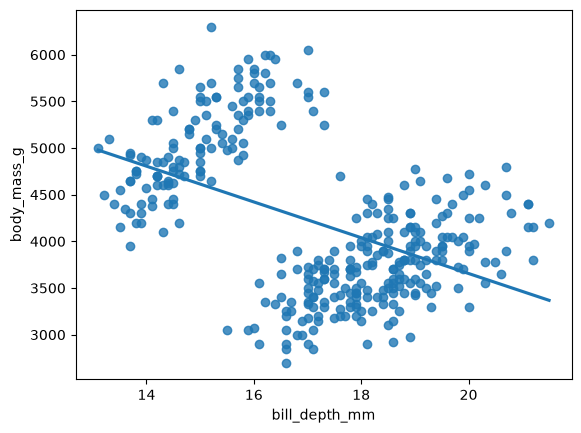

In [5]:
#scatterplot
sns.regplot(data=penguins, x="bill_depth_mm", y="body_mass_g", ci=None)

Describe the direction and strength of the relationship. Is the direction what you would have expected? 

Body mass and Bill depth appear to have a negatively weak relationship. I thought it would show a positive relationship since I thought higher body mass would have larger bills but from the graph it appears to be the oposite. 


PART B: Using only numpy and/or pandas — no sklearn, no statsmodels — compute ₀ and ₁ 
from the ordinary least squares formulas we derived in class. Report the estimated regression 
equation, and interpret the slope in the units of the data in one sentence. 

In [6]:
#linear regression model for sklearn
from sklearn.linear_model import LinearRegression

X = peng_subset[['bill_depth_mm']]  
y = peng_subset['body_mass_g']    

model = LinearRegression().fit(X, y)
print(model.coef_, model.intercept_)

print(f"body_mass_g = {model.intercept_:.2f} + {model.coef_[0]:.2f} * bill_depth_mm")
print(f"R^2 = {model.score(X, y):.4f}")

[-191.64279133] 7488.652400935164
body_mass_g = 7488.65 + -191.64 * bill_depth_mm
R^2 = 0.2227


In [7]:
#linear regression model for statmodel
X = sm.add_constant(peng_subset["bill_depth_mm"])
y = peng_subset["body_mass_g"]

results = sm.OLS(y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     97.41
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.28e-20
Time:                        18:26:46   Log-Likelihood:                -2728.7
No. Observations:                 342   AIC:                             5461.
Df Residuals:                     340   BIC:                             5469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7488.6524    335.218     22.340

In [8]:
# b0 and b1 from OLS formula (used to check sklearn and statmodel)
x = peng_subset['bill_depth_mm']
y = peng_subset['body_mass_g']

x_bar, y_bar = x.mean(), y.mean()

b1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
b0 = y_bar - b1 * x_bar

print(f"manual:       b0 = {b0:.4f}, b1 = {b1:.4f}")
print(f"sklearn:      b0 = {model.intercept_:.4f}, b1 = {model.coef_[0]:.4f}")
print(f"statsmodels:  b0 = {results.params.iloc[0]:.4f}, b1 = {results.params.iloc[1]:.4f}")

manual:       b0 = 7488.6524, b1 = -191.6428
sklearn:      b0 = 7488.6524, b1 = -191.6428
statsmodels:  b0 = 7488.6524, b1 = -191.6428


Regression equation: y.mean() 7488.6524 -191.6428 * X

Slope: For each unit of x, there is an decrease of -191.6428.

PART C: Calculate RSE using the formula we discussed in class (see slide 35). Also calculate R2 by first calculating the correlation between bill depth and body mass. What are each of these 
numbers telling you

In [10]:
# Predicted values and residuals
y_hat = b0 + b1 * x
residuals = y - y_hat

# n defining
n = len(x)

# RSE
rss = np.sum(residuals**2)
rse = np.sqrt(rss / (n - 2))

# R^2
r = np.corrcoef(x, y)[0, 1]
r_squared = r**2

print(f"RSE: {rse:.4f}")
print(f"Correlation (r): {r:.4f}")
print(f"R-squared (R2): {r_squared:.4f}")

RSE: 708.0772
Correlation (r): -0.4719
R-squared (R2): 0.2227


RSE: The predicted model is different from the observed body mass by 708.0772
Correlation: There is a negavtive relationship between variables
R^2: There is a 22.27% variablity in body mass 

Usage of AI:
I used GenAI to help explain concepts, such as RSE and R2 for part C by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

PART 2: How Good Is This Model? (12 pts)

Part A: Now use statsmodels to predict body mass from bill depth. For the slope (₁), note the 
standard error, t-statistic, and p-value. State the null and alternative hypotheses that this t-test is evaluating, and what you can conclude based on these numbers. 

In [ ]:
#linear regression model for statmodel
X = sm.add_constant(peng_subset["bill_depth_mm"])
y = peng_subset["body_mass_g"]

results = sm.OLS(y, X).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     97.41
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           2.28e-20
Time:                        18:13:43   Log-Likelihood:                -2728.7
No. Observations:                 342   AIC:                             5461.
Df Residuals:                     340   BIC:                             5469.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          7488.6524    335.218     22.340

null hypotheses: there is no relationship between bill depth and body mass
alternative hypotheses: there is a relationshop between bill depth and body mass
what you can conclude based on these numbers: 
- p-value is 0, to reject the null hypothesis --> there is a relationship/correlation

PART B: Now look specifically at the R² for this model and the p-value for the slope. Discuss what each of these numbers is measuring, what they are collectively telling you

p value is meassuring the correlation between variables, while the r^2 is meassuring the variability od the model.
- p-value is 0, to reject the null hypothesis --> there is a relationship/correlation
- r^2 represents a 22.3% in variability in body mass by bill depth

PART C: 

PART C: A

In [12]:
#Bootstraping
rng = np.random.default_rng(42)   # seed so class results are reproducible
n_boot = 10000
n = len(peng_subset) # number of samples in each simulation

# We will use x and y as defined above and convert to numpy. 
x = peng_subset['bill_depth_mm']
y = peng_subset['body_mass_g']
xv, yv = x.to_numpy(), y.to_numpy()
boot = np.empty((n_boot, 2)) #initialize an array of empty tuples

In [ ]:
for i in range(n_boot):                  # Do this 10000 times
    idx = rng.integers(0, n, n)          # sample n rows WITH replacement
    xb, yb = xv[idx], yv[idx]            # generate pairs of x and y from dataset
    xm, ym = xb.mean(), yb.mean()        # calculate means
    slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum() #calculate b1
    boot[i] = (ym - slope * xm, slope)   # save b0 and b1 for this simulation

In [15]:
#data frame bootstrap
boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])

# The 95% confidence interval is given by the middle 95% of this distribution
# We can use the quantile function to find this
# We can also compare with the values from statsmodels

analytic_ci = results.conf_int()

comparison = pd.DataFrame({
    'estimate (full sample)': [b0, b1],
    'bootstrap mean':         [boot_df['b0'].mean(), boot_df['b1'].mean()],
    'CI low (formula)':       analytic_ci[0].to_numpy(),
    'CI low (bootstrap)':     [boot_df['b0'].quantile(.025), boot_df['b1'].quantile(.025)],
    'CI high (formula)':      analytic_ci[1].to_numpy(),
    'CI high (bootstrap)':    [boot_df['b0'].quantile(.975), boot_df['b1'].quantile(.975)],
}, index=['b0', 'b1'])

comparison.round(3).T

,b0,b1
estimate (full sample),7488.652,-191.643
bootstrap mean,7496.018,-192.057
CI low (formula),6829.290,-229.835
CI low (bootstrap),6959.090,-223.878
CI high (formula),8148.014,-153.450
CI high (bootstrap),8059.257,-161.913


Which gives narrower confidence intervals, statsmodels or the bootstrap? What does that 
tell you? 

This results in a tighter confidence interval for both intercept and slope as compared to the statsmodels. Therefore, the parametric equation, statsmodels, is the method since it adds more variance to the sample because of the assumptions that it holds but which the bootstrapping does not. This means that the true variance of the sample is a little bit less than that which is expected using the parametric equation, and this is most likely because of errors.

PART C: B

In [21]:
#2.5 and 97.5 percentiles
b0_ci_boot = (boot_df['b0'].quantile(0.025), boot_df['b0'].quantile(0.975))
b1_ci_boot = (boot_df['b1'].quantile(0.025), boot_df['b1'].quantile(0.975))

print(f"Bootstrap 95% CI for b0: ({b0_ci_boot[0]:.4f}, {b0_ci_boot[1]:.4f})")
print(f"Bootstrap 95% CI for b1: ({b1_ci_boot[0]:.4f}, {b1_ci_boot[1]:.4f})\n")

# Get statsmodels 95% CI for comparison
print("Statsmodels 95% CI:")
print(results.conf_int())


Bootstrap 95% CI for b0: (6959.0903, 8059.2567)
Bootstrap 95% CI for b1: (-223.8780, -161.9129)

Statsmodels 95% CI:
                         0            1
const          6829.290428  8148.014374
bill_depth_mm  -229.835335  -153.450247


What assumption does the formula-based interval make that the bootstrap does not? 

Interval estimation with the formula approach of the regression residuals, thus allowing for the application of the t-distribution to derive the standard error. The bootstrap does not make any assumptions about the shape of the distribution and simply resamples the data and estimates directly from the sampling distribution of the coefficient. 

PART C: C

In [ ]:
# Turn the bootstrap procedure into a function so we can rerun it easily
def run_bootstrap(n_boot, seed=None):
    rng = np.random.default_rng(seed)
    boot = np.empty((n_boot, 2))
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        xb, yb = xv[idx], yv[idx]
        xm, ym = xb.mean(), yb.mean()
        slope = ((xb - xm) * (yb - ym)).sum() / ((xb - xm) ** 2).sum()
        boot[i] = (ym - slope * xm, slope)
    boot_df = pd.DataFrame(boot, columns=['b0', 'b1'])
    b0_ci = (boot_df['b0'].quantile(0.025), boot_df['b0'].quantile(0.975))
    b1_ci = (boot_df['b1'].quantile(0.025), boot_df['b1'].quantile(0.975))
    return b0_ci, b1_ci


In [38]:
# PART C: c - change the random seed (or leave it unset) and rerun with B=10000
b0_ci_newseed, b1_ci_newseed = run_bootstrap(10000, seed=123)  # try a few different seed values
print(f"New seed - Bootstrap 95% CI for b0: ({b0_ci_newseed[0]:.4f}, {b0_ci_newseed[1]:.4f})")
print(f"New seed - Bootstrap 95% CI for b1: ({b1_ci_newseed[0]:.4f}, {b1_ci_newseed[1]:.4f})")

# Compare to your original seed=42 result
print(f"\nOriginal (seed=42) - b0: ({b0_ci_boot[0]:.4f}, {b0_ci_boot[1]:.4f})")
print(f"Original (seed=42) - b1: ({b1_ci_boot[0]:.4f}, {b1_ci_boot[1]:.4f})")

New seed - Bootstrap 95% CI for b0: (6968.5791, 8051.6942)
New seed - Bootstrap 95% CI for b1: (-223.0205, -162.3383)

Original (seed=42) - b0: (6959.0903, 8059.2567)
Original (seed=42) - b1: (-223.8780, -161.9129)


PART C: D

In [39]:
# PART C: d - repeat the bootstrap 10 times each at B=1000 and B=100
results_1000 = [run_bootstrap(1000) for _ in range(10)]
results_100  = [run_bootstrap(100)  for _ in range(10)]

# Build a summary table of the 2.5th/97.5th percentile bounds across the 10 runs
def summarize(results, B):
    b0_los = [r[0][0] for r in results]
    b0_his = [r[0][1] for r in results]
    b1_los = [r[1][0] for r in results]
    b1_his = [r[1][1] for r in results]
    return pd.DataFrame({
        'B': [B]*10,
        'run': range(1, 11),
        'b0_low': b0_los, 'b0_high': b0_his,
        'b1_low': b1_los, 'b1_high': b1_his
    })

summary_1000 = summarize(results_1000, 1000)
summary_100  = summarize(results_100, 100)

print("B=1000 results:")
print(summary_1000.round(3))
print("\nB=100 results:")
print(summary_100.round(3))

B=1000 results:
      B  run    b0_low   b0_high   b1_low  b1_high
0  1000    1  6978.228  8056.839 -222.493 -162.995
1  1000    2  6962.650  8048.655 -223.171 -161.444
2  1000    3  6974.187  7994.749 -221.081 -163.592
3  1000    4  6950.186  8013.643 -221.399 -161.238
4  1000    5  6987.254  8072.488 -224.888 -164.076
5  1000    6  6953.986  8044.018 -223.151 -162.967
6  1000    7  6927.427  8037.711 -223.005 -160.867
7  1000    8  6941.197  8071.326 -224.865 -160.822
8  1000    9  6998.263  8014.496 -221.794 -164.177
9  1000   10  7001.582  8080.536 -224.424 -163.417

B=100 results:
     B  run    b0_low   b0_high   b1_low  b1_high
0  100    1  6954.271  8045.639 -222.868 -162.339
1  100    2  6970.513  8036.385 -221.414 -163.300
2  100    3  6953.050  8040.247 -221.391 -160.881
3  100    4  7040.437  8057.506 -221.561 -164.473
4  100    5  6933.621  8082.804 -226.191 -160.444
5  100    6  6972.030  7996.061 -219.762 -162.274
6  100    7  6852.477  8112.997 -230.528 -156.912
7  100 

In [40]:
# Look at how much the CI bounds vary across the 10 runs, for each B
for label, df in [('B=100', summary_100), ('B=1000', summary_1000)]:
    print(f"\n{label}:")
    print(f"  b0_low  range: {df['b0_low'].min():.3f} to {df['b0_low'].max():.3f}  (spread={df['b0_low'].max()-df['b0_low'].min():.3f})")
    print(f"  b0_high range: {df['b0_high'].min():.3f} to {df['b0_high'].max():.3f}  (spread={df['b0_high'].max()-df['b0_high'].min():.3f})")
    print(f"  b1_low  range: {df['b1_low'].min():.3f} to {df['b1_low'].max():.3f}  (spread={df['b1_low'].max()-df['b1_low'].min():.3f})")
    print(f"  b1_high range: {df['b1_high'].min():.3f} to {df['b1_high'].max():.3f}  (spread={df['b1_high'].max()-df['b1_high'].min():.3f})")



B=100:
  b0_low  range: 6852.477 to 7094.918  (spread=242.440)
  b0_high range: 7953.720 to 8112.997  (spread=159.277)
  b1_low  range: -230.528 to -219.191  (spread=11.337)
  b1_high range: -168.858 to -156.912  (spread=11.945)

B=1000:
  b0_low  range: 6927.427 to 7001.582  (spread=74.155)
  b0_high range: 7994.749 to 8080.536  (spread=85.788)
  b1_low  range: -224.888 to -221.081  (spread=3.807)
  b1_high range: -164.177 to -160.822  (spread=3.355)


What information does this give you about the value of B in your bootstrap simulation? 

Considering the comparison of the 10 repeated simulations with each value of B, you can conclude that the most variable CI bounds such as the 2.5th and 97.5th percentiles were observed when B = 100 – the low and high CI bounds for β₀ and β₁ are different from one another. At B = 10000, the CI bounds were consistent from one to another and demonstrate no variability at all. This fact means that the value of B is not an indication of the uncertainty of the data itself. 

Usage of AI:
I used GenAI to help explain concepts, such as bootstraping for part C by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

PART 3: Residuals

PART A: Plot fitted values vs. residuals for your bill depth model you just built. Please also 
replicate the fitted vs residuals plot we looked at in class for the model predicting mass as a 
function of flipper length. Compare these plots side by side. What is each of these plots telling 
you about the respective models?  

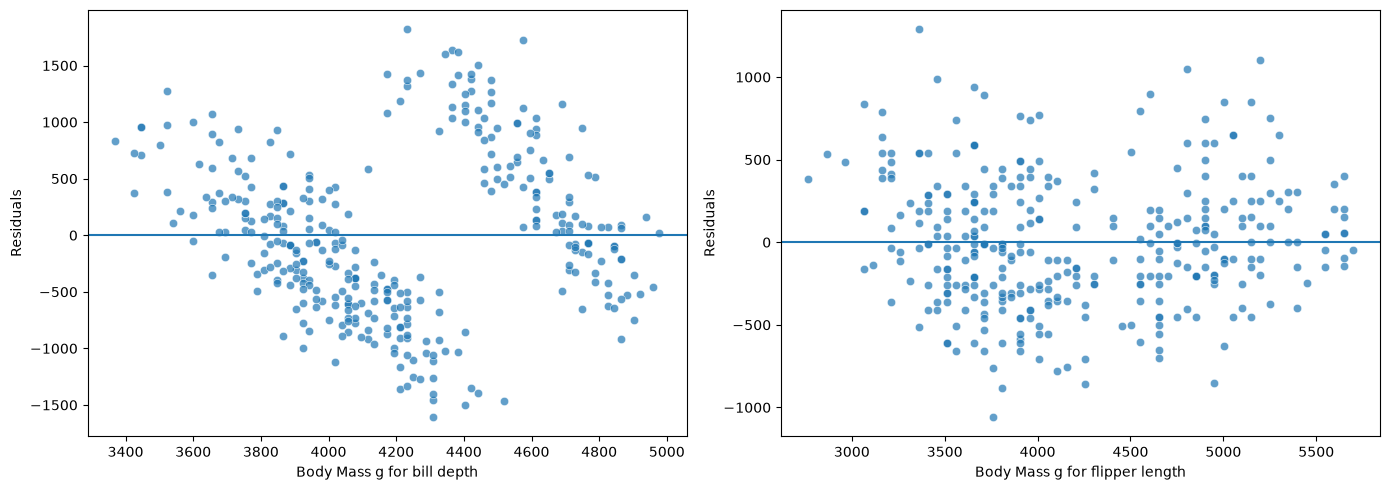

In [35]:
# Bill Depth Model
X_bill = sm.add_constant(peng_subset['bill_depth_mm'])
model_bill = sm.OLS(peng_subset['body_mass_g'], X_bill).fit()
fitted_bill = model_bill.fittedvalues
resids_bill = model_bill.resid

# Flipper Length Model
X_flip = sm.add_constant(peng_subset['flipper_length_mm'])
model_flip = sm.OLS(peng_subset['body_mass_g'], X_flip).fit()
fitted_flip = model_flip.fittedvalues
resids_flip = model_flip.resid

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bill Depth Model Residuals
sns.scatterplot(x=fitted_bill, y=resids_bill, ax=axes[0], alpha=0.7)
axes[0].axhline(0)
axes[0].set_xlabel("Body Mass g for bill depth")
axes[0].set_ylabel("Residuals")

# Flipper Length Model Residuals
sns.scatterplot(x=fitted_flip, y=resids_flip, ax=axes[1], alpha=0.7)
axes[1].axhline(0)
axes[1].set_xlabel("Body Mass g for flipper length")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Compare these plots side by side. What is each of these plots telling you about the respective models? 

Bill depth: 
- clustered into groups
- closer grouped around the zero line

Flipper length:
- more spread apart from each other 
- equally scattered around the zero line
- better graph to represent body mass and flipper length

PART B:

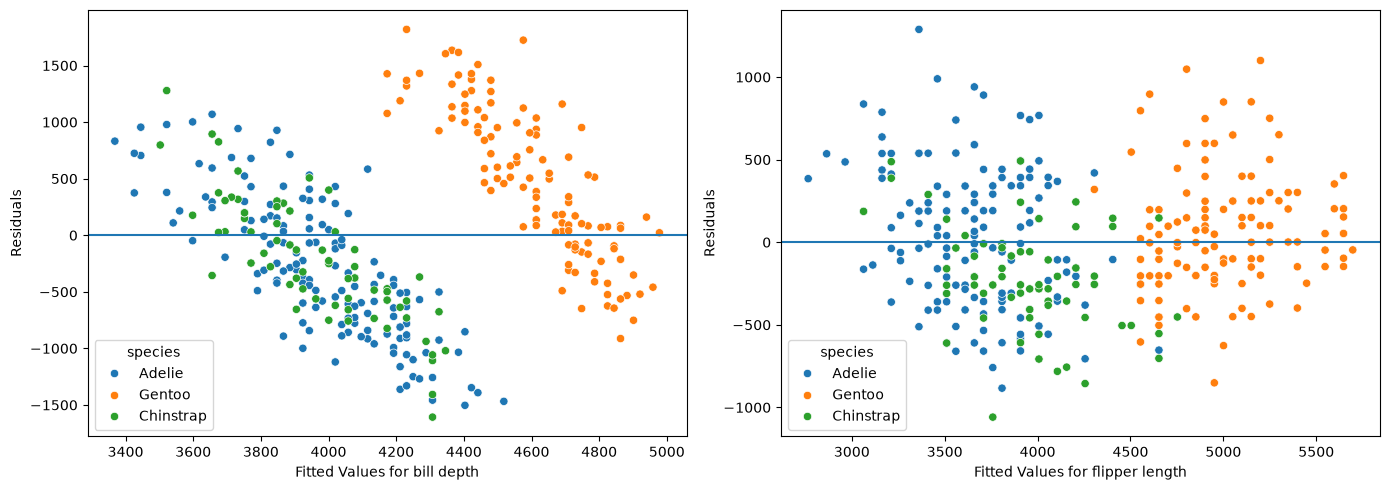

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=fitted_bill, y=resids_bill, hue=peng_subset['species'], ax=axes[0])
axes[0].axhline(0)
axes[0].set_xlabel("Fitted Values for bill depth")
axes[0].set_ylabel("Residuals")

sns.scatterplot(x=fitted_flip, y=resids_flip, hue=peng_subset['species'], ax=axes[1])
axes[1].axhline(0)
axes[1].set_xlabel("Fitted Values for flipper length")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Describe what you see in each:
Bill depth:
- it shows the gentoo species has a higher fitted value than adelie and chinstrap
- adelie and chinstrap appear to be clustered around each other, while gentoo is all clustered together 

Flipper length: 
- it shows the gentoo species has a higher fitted value than adelie and chinstrap
- adelie and chinstrap appear to be spread around each other

PART C:

In [26]:
# Correlation all of them
r_overall = peng_subset['bill_depth_mm'].corr(peng_subset['body_mass_g'])
print(f"Overall Correlation (Bill Depth vs Body Mass): {r_overall:.4f}\n")

# Correlation within each species
print("Correlation within each species:")
species_corr = peng_subset.groupby('species')[['bill_depth_mm', 'body_mass_g']].corr().iloc[0::2, 1]
print(species_corr)

Overall Correlation (Bill Depth vs Body Mass): -0.4719

Correlation within each species:
species                 
Adelie     bill_depth_mm    0.576138
Chinstrap  bill_depth_mm    0.604498
Gentoo     bill_depth_mm    0.719085
Name: body_mass_g, dtype: float64


Explain what's going on:
The overall correaltion represents a negative correlation while each seperate correlation for each species demonstrates a positive correlations. So while bill_depth_mm increase and body_mass_g also increase for each species. 

PART D:

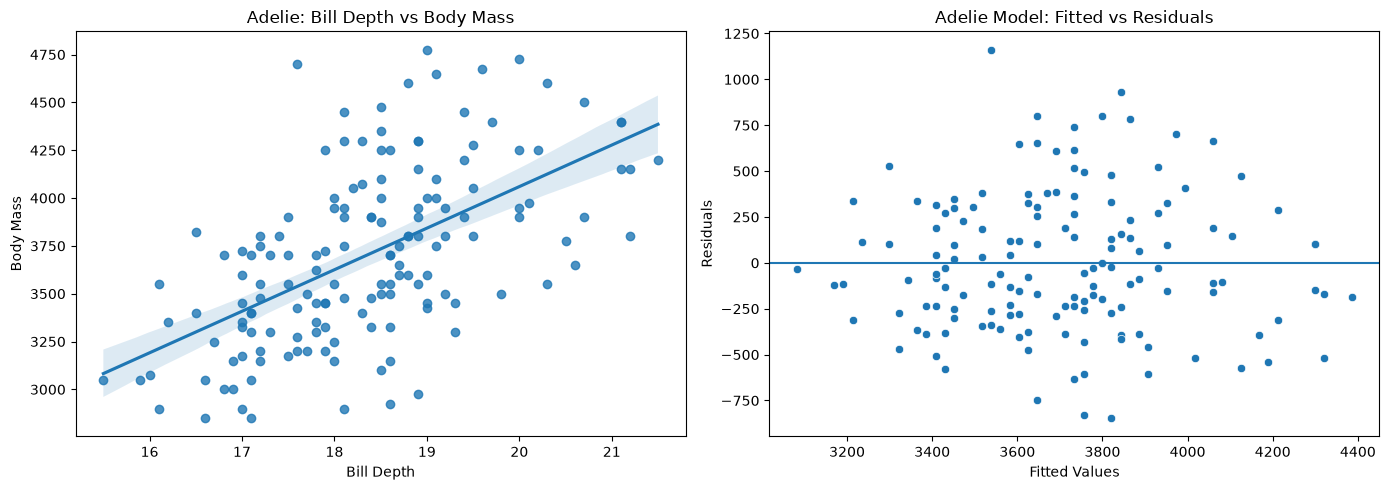

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.332
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     74.03
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           9.94e-15
Time:                        21:34:04   Log-Likelihood:                -1108.6
No. Observations:                 151   AIC:                             2221.
Df Residuals:                     149   BIC:                             2227.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -283.2787    464.033     -0.610

In [47]:
adelie_df = peng_subset[peng_subset['species'] == 'Adelie']

X_adelie = sm.add_constant(adelie_df['bill_depth_mm'])
model_adelie = sm.OLS(adelie_df['body_mass_g'], X_adelie).fit()

# Bill Depth vs Body Mass & Fitted vs Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regression Line Plot
sns.regplot(data=adelie_df, x='bill_depth_mm', y='body_mass_g', ax=axes[0])
axes[0].set_title("Adelie: Bill Depth vs Body Mass")
axes[0].set_xlabel("Bill Depth")
axes[0].set_ylabel("Body Mass")

# Residual Plot
sns.scatterplot(x=model_adelie.fittedvalues, y=model_adelie.resid, ax=axes[1])
axes[1].axhline(0)
axes[1].set_title("Adelie Model: Fitted vs Residuals")
axes[1].set_xlabel("Fitted Values")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

print(model_adelie.summary())

What conclusions would you draw for just the Adelies? Reflect on how this is related to the conclusions you drew for all penguins.  

The conclusion I made for all the penguins is that there was a negative correlation, which is different when focused on each individual species. When the Adelie penguins data was seperately meassure it demonstrated a positive relationship between mass and bill depth. 

Usage of AI:
I used GenAI to help explain concepts, such as scatterplots, residual, and correlation for part D, A, and C by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

PART 4: Multiple Linear Regression (8 pts) 

PART A:

Look at the formulas of R2 and Adj R2 that we went over in class. Why do these two values behave differently? How does their behavior differ as more predictors are added. (Hint: The recommended reading will help with insight here as well.)

The R^2 measures the raw share of variance in body mass explained by the model. Since the fitting process can shrink an unhelpful coefficient toward zero rather than let it hurt the fit, it never decreases. The adjusted R² penalizes the number of predictors relative to the sample size. When a new predictor improves for more than chance alone would predict, adjusted R² rises.

PART B:

In [50]:
cols = ['body_mass_g', 'flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']
clean_df = peng_subset[cols].dropna()

y = clean_df['body_mass_g']

# flipper_length_mm
X1 = sm.add_constant(clean_df[['flipper_length_mm']])
m1 = sm.OLS(y, X1).fit()

# flipper_length_mm + bill_depth_mm
X2 = sm.add_constant(clean_df[['flipper_length_mm', 'bill_depth_mm']])
m2 = sm.OLS(y, X2).fit()

# flipper_length_mm + bill_depth_mm + bill_length_mm
X3 = sm.add_constant(clean_df[['flipper_length_mm', 'bill_depth_mm', 'bill_length_mm']])
m3 = sm.OLS(y, X3).fit()

# Comparison Table
results_data = {
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Predictors": [
        "flipper_length_mm",
        "flipper_length_mm + bill_depth_mm",
        "flipper_length_mm + bill_depth_mm + bill_length_mm"
    ],
    "R2": [m1.rsquared, m2.rsquared, m3.rsquared],
    "Adj R2": [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    "RSE": [np.sqrt(m1.mse_resid), np.sqrt(m2.mse_resid), np.sqrt(m3.mse_resid)],
    "F-statistic": [m1.fvalue, m2.fvalue, m3.fvalue]
}

comparison_df = pd.DataFrame(results_data)
print(comparison_df.to_string(index=False))


  Model                                         Predictors       R2   Adj R2        RSE  F-statistic
Model 1                                  flipper_length_mm 0.758993 0.758284 394.278178  1070.744592
Model 2                  flipper_length_mm + bill_depth_mm 0.761040 0.759630 393.178380   539.823944
Model 3 flipper_length_mm + bill_depth_mm + bill_length_mm 0.761470 0.759353 393.404797   359.671804


For each of these models, create a table reporting R², adjusted R², RSE, and the F-statistic 
for each. Which model would you choose, and why? 

I would choose Model 3. When going from Model 1 to 3, the R^2 and adjusted R² increases while the residual standard error decreases. 

PART C:

In [53]:
print(f"bill_depth_mm coef: {m2.params['bill_depth_mm']:.4f}")

bill_depth_mm coef: 22.6341


What happened, and why? Use the interpretation of βⱼ from class — the average effect of a one unit increase in that predictor, holding the other predictors fixed — in your explanation.

In the simple regression, Model 1  coefficient is negative (= -191.64). When flipper_length_mm is added, the coefficient is positive. Since the multiple-regression coefficient is a partial effect, it holds the flipper length constant. When you compare the penguins of similar flippers, it tracks a larger, heavier bird thus flipping the sign.

PART D:

In [52]:
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          8.19e-105
Time:                        22:08:27   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -6424.7647    561.46

Null hypo: There is no relationship between variables
Alter hypo: There is a relationship between at least one variable 
what you conclude from it: The null hypothesis is rejected because there is a correlation with all the varibales and body mass.

Usage of AI:
I used GenAI to help explain concepts, such as R^2 and comparison tables for part B and D by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 

PART 5: Modeling with the Planets Dataset (10 pts)

PART A:

In [57]:
planets = pd.read_csv("PlanetsData.csv")
planets

,planet,distance,diameter,revolution,position
0,Mercury,36,3030,88,1
1,Venus,67,7520,225,2
2,Earth,93,7926,365,3
3,Mars,142,4217,687,4
4,Jupiter,484,88838,4332,5
5,Saturn,887,74896,10760,6
6,Uranus,1765,31762,30684,7
7,Neptune,2791,30774,60188,8
8,Pluto,3654,1428,90467,9


In [66]:
#comparison Table 
comp_a = planets[['planet', 'distance', 'revolution', 'pred_lin']].copy()
comp_a.columns = ['Planet', 'Distance (M mi)', 'Actual Revolution', 'Predicted (Linear)']
print(comp_a.to_string(index=False))


 Planet  Distance (M mi)  Actual Revolution  Predicted (Linear)
Mercury               36                 88        -3711.348645
  Venus               67                225        -2964.382280
  Earth               93                365        -2337.894361
   Mars              142                687        -1157.205590
Jupiter              484               4332         7083.520113
 Saturn              887              10760        16794.082858
 Uranus             1765              30684        37950.097969
Neptune             2791              60188        62672.275081
  Pluto             3654              90467        83466.854854


Judging by R² alone, how good does this model look? Compare actual and predicted values for each of the planets. 
Now look at the predicted revolution for the four innermost planets? What does that tell you? 

The R^2 value of the linear model is extremely high from .988 to .99. The model predicts that the four innermost planets have negative or zero revolution times. However, the R^2 value can be misleading due to outliers such as neptune or pluto.

PART B:

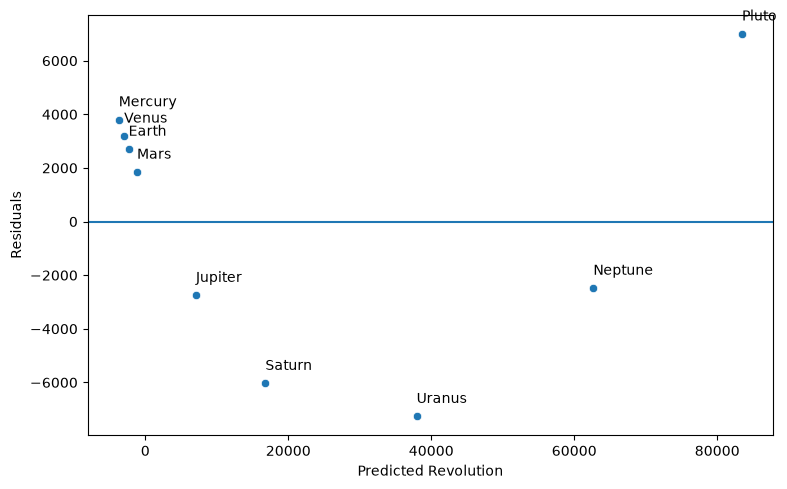

In [67]:
#plot model
plt.figure(figsize=(8, 5))
sns.scatterplot(x=planets['pred_lin'], y=planets['resid_lin'])
plt.axhline(0)
for i, txt in enumerate(planets['planet']):
    plt.annotate(txt, (planets['pred_lin'].iloc[i], planets['resid_lin'].iloc[i] + 500))
plt.xlabel("Predicted Revolution")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

What do you see? Which planets have the largest residuals, and in which direction? What does this tell you about the validity of the linear model for this dataset?

In this residual plot, it exhibits a severe non-linear U-shaped pattern. Both neptune and plute are considered the largest residuals because they have massive positive and negative residuals. From this data, we can conclude that a simple linear model is invalid for this relationship because of the severe curve present.

PART C:

In [71]:
#part a:
#transformation to distance (x) and revolution (y)
planets['log_distance'] = np.log(planets['distance'])
planets['log_revolution'] = np.log(planets['revolution'])

#predictors and response variable
X_log = sm.add_constant(planets['log_distance'])
y_log = planets['log_revolution']

#OLS linear model
model_log = sm.OLS(y_log, X_log).fit()

print(model_log.summary())


                            OLS Regression Results                            
Dep. Variable:         log_revolution   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.585e+06
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           5.26e-20
Time:                        22:55:33   Log-Likelihood:                 34.696
No. Observations:                   9   AIC:                            -65.39
Df Residuals:                       7   BIC:                            -65.00
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.9031      0.007   -122.147   

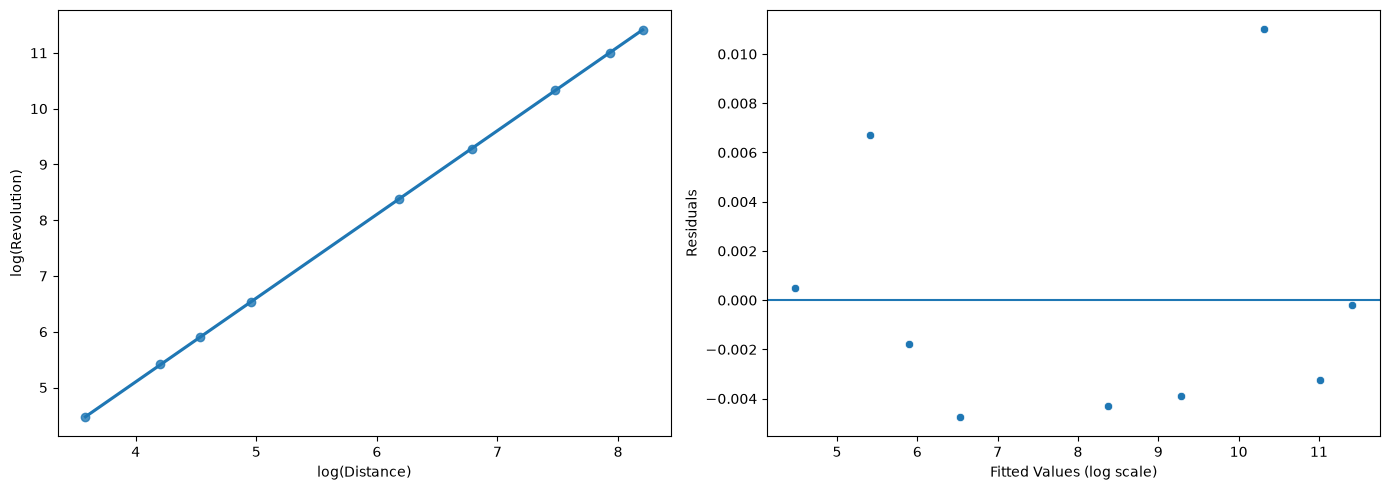

In [70]:
#part b:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter with regression line
sns.regplot(x='log_distance', y='log_revolution', data=planets, ax=axes[0])
axes[0].set_xlabel("log(Distance)")
axes[0].set_ylabel("log(Revolution)")

# Residual plot
sns.scatterplot(x=model_log.fittedvalues, y=model_log.resid, ax=axes[1])
axes[1].axhline(0)
axes[1].set_xlabel("Fitted Values (log scale)")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

Compare this to the model you built in part a. Is this a better fit? 
Yes this is a better fit!

PART C:

In [72]:
#R2 and slope coefficient
r2_log = model_log.rsquared
slope = model_log.params['log_distance']
intercept = model_log.params['const']

print(f"New R-squared: {r2_log:.6f}")
print(f"Estimated Slope: {slope:.4f}")
print(f"Estimated Intercept: {intercept:.4f}")

New R-squared: 0.999996
Estimated Slope: 1.5013
Estimated Intercept: -0.9031


Report the new R² and the estimated slope. The slope should land very close to a simple fraction — what is it? 

The new R^2 value of the log-log model is .999999 or ~1.0, and the estimated slope is 1.50 which is 3/2 in fractional terms.

PART D:

In [73]:
#predicted log-revolution to actual days for exp()
planets['pred_log_back'] = np.exp(model_log.fittedvalues)

comp_d = planets[['planet', 'distance', 'revolution', 'pred_lin', 'pred_log_back']].copy()
comp_d.columns = ['Planet', 'Distance', 'Actual Rev', 'Linear Model Pred', 'Log-Log Model Pred']

comp_d['Linear Error'] = np.abs(comp_d['Actual Rev'] - comp_d['Linear Model Pred'])
comp_d['Log-Log Error'] = np.abs(comp_d['Actual Rev'] - comp_d['Log-Log Model Pred'])

print(comp_d.to_string(index=False))

 Planet  Distance  Actual Rev  Linear Model Pred  Log-Log Model Pred  Linear Error  Log-Log Error
Mercury        36          88       -3711.348645           87.955672   3799.348645       0.044328
  Venus        67         225       -2964.382280          223.498426   3189.382280       1.501574
  Earth        93         365       -2337.894361          365.655904   2702.894361       0.655904
   Mars       142         687       -1157.205590          690.272590   1844.205590       3.272590
Jupiter       484        4332        7083.520113         4350.622150   2751.520113      18.622150
 Saturn       887       10760       16794.082858        10802.199220   6034.082858      42.199220
 Uranus      1765       30684       37950.097969        30348.267640   7266.097969     335.732360
Neptune      2791       60188       62672.275081        60383.237531   2484.275081     195.237531
  Pluto      3654       90467       83466.854854        90486.168764   7000.145146      19.168764


How close is the new model to reality vs the linear model?  
 
The results from the log-log model practically aligns with real-world orbital periods across all planets. This is due to how this model yields zero prediction errors compared to the thousands of data of error in the raw linear model.

Usage of AI:
I used GenAI to help explain concepts, such as transformation in distance & revolution and coefficient in part C by suggesting beginner-friendly way to approach the problem. I did not rely on the generated answers without checking them with my class notebook examples and I tested the code in Jupyter Notebook. 